<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/09_GrangerCausality_VAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9 실습: Granger 인과성, 충격반응, 분산분해
**Notebook:** `09_GrangerCausality_VAR.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 그랜저 인과성(Granger Causality)의 의미를 실제 데이터로 이해합니다.
2. 다변량 거시경제 시계열을 VAR 시스템으로 구성합니다.
3. 정보 기준을 통해 적절한 시차(lag)를 선택합니다.
4. 그랜저 인과성 검정을 수행하여 예측 선행성을 확인합니다.
5. 충격반응함수(IRF)를 이용해 충격의 동적 파급 경로를 시각화합니다.
6. 예측오차 분산분해(FEVD)를 이용해 각 변수 변동성의 기여도를 해석합니다.
7. 결과를 “철학적 인과성”이 아니라 “통계적 예측 선행성”의 관점에서 해석합니다.

---

## 왜 이 실습이 중요한가?
VAR 모형을 적합한 뒤 계수표만 보는 것은 실무적으로 한계가 큽니다.  
실제 분석에서는 오히려 다음 질문이 더 중요합니다.

- 어떤 변수의 과거가 다른 변수의 미래 예측에 도움을 주는가?
- 한 변수에 발생한 충격이 다른 변수로 얼마나 오래, 얼마나 크게 전파되는가?
- 특정 변수의 예측 불확실성은 자기 자신의 충격 때문인가, 아니면 다른 변수의 충격 때문인가?

이번 실습은 바로 이 질문들에 답하는 **그랜저 인과성, IRF, FEVD**를 하나의 흐름으로 연결하는 데 목적이 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [2]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 2. 실습용 거시경제 데이터 불러오기
이번 실습에서는 `statsmodels`에 포함된 **macrodata**를 사용합니다.

변수는 다음 세 가지입니다.

- `realgdp`: 실질 GDP
- `realcons`: 실질 소비
- `realinv`: 실질 투자

이 변수들은 수준(level) 데이터이므로, VAR/그랜저 분석을 위해 먼저 로그 차분을 통해 성장률 시계열로 변환합니다.


In [3]:
# ============================================
# 3. macrodata 로드
# ============================================

import statsmodels.api as sm

macro = sm.datasets.macrodata.load_pandas().data.copy()
print("Raw shape:", macro.shape)
display(macro.head())


Raw shape: (203, 14)


,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


## 3. 분기 인덱스와 성장률 시계열 생성
macrodata는 `year`, `quarter` 컬럼을 포함합니다.  
여기서는 분기 인덱스를 만들고, 로그 차분(log difference × 100)을 통해 성장률에 가까운 시계열을 구성합니다.


In [4]:
# ============================================
# 4. 분기 인덱스 생성 + 로그 차분
# ============================================

dates = pd.date_range(start="1959-03-31", periods=len(macro), freq="QE")

data = pd.DataFrame({
    "gdp_growth": np.log(macro["realgdp"].values),
    "cons_growth": np.log(macro["realcons"].values),
    "inv_growth": np.log(macro["realinv"].values)
}, index=dates)

data = data.diff() * 100
data = data.dropna()

print("Transformed shape:", data.shape)
display(data.head())


Transformed shape: (202, 3)


,gdp_growth,cons_growth,inv_growth
1959-06-30,2.494213,1.528611,8.021268
1959-09-30,-0.119295,1.038598,-7.213104
1959-12-31,0.349453,0.108401,3.442511
1960-03-31,2.219018,0.953415,10.266377
1960-06-30,-0.468455,1.257243,-10.669385


## 4. 시계열 플롯 확인
먼저 세 변수의 성장률 시계열을 그려 공통 충격과 변동성을 관찰합니다.


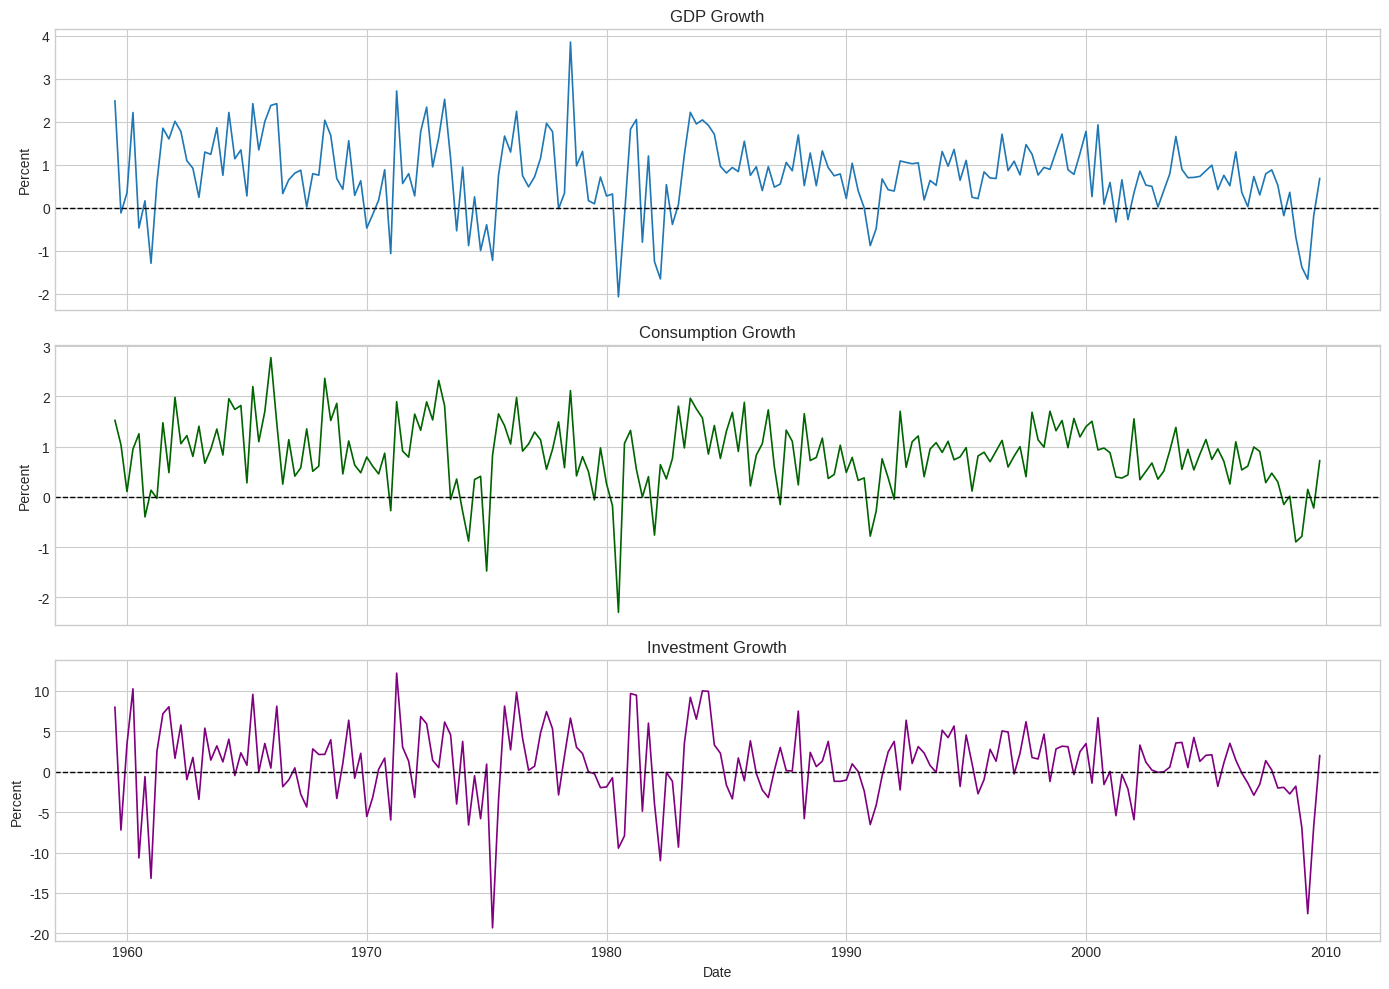

In [5]:
# ============================================
# 5. 다변량 성장률 플롯
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(data.index, data["gdp_growth"], linewidth=1.2)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("GDP Growth")
axes[0].set_ylabel("Percent")

axes[1].plot(data.index, data["cons_growth"], linewidth=1.2, color="darkgreen")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Consumption Growth")
axes[1].set_ylabel("Percent")

axes[2].plot(data.index, data["inv_growth"], linewidth=1.2, color="purple")
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Investment Growth")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Percent")

plt.tight_layout()
plt.show()


## 5. 정상성 점검
그랜저 인과성과 VAR 해석은 일반적으로 정상 시계열을 전제로 합니다.  
따라서 성장률 데이터에 대해 ADF 검정을 수행합니다.

- 귀무가설: 단위근이 존재한다 (비정상)
- p-value가 충분히 작으면 정상성에 더 가까움


In [6]:
# ============================================
# 6. ADF 검정 함수
# ============================================

from statsmodels.tsa.stattools import adfuller

def adf_report(series, name="Series"):
    result = adfuller(pd.Series(series).dropna(), autolag="AIC")
    print(f"===== {name} =====")
    print("ADF Statistic :", round(result[0], 4))
    print("ADF p-value   :", round(result[1], 4))
    print("-" * 40)


In [7]:
# ============================================
# 7. 각 변수의 ADF 검정
# ============================================

for col in data.columns:
    adf_report(data[col], col)


===== gdp_growth =====
ADF Statistic : -6.9729
ADF p-value   : 0.0
----------------------------------------
===== cons_growth =====
ADF Statistic : -4.992
ADF p-value   : 0.0
----------------------------------------
===== inv_growth =====
ADF Statistic : -12.219
ADF p-value   : 0.0
----------------------------------------


## 6. VAR 시차 선택
그랜저 인과성, IRF, FEVD는 적절한 VAR 시차 선택 위에서 해석되어야 합니다.  
시차가 너무 작으면 동학을 놓치고, 너무 크면 과적합과 자유도 손실이 커집니다.


In [8]:
# ============================================
# 8. VAR lag selection
# ============================================

from statsmodels.tsa.vector_ar.var_model import VAR

var_selector = VAR(data)
lag_selection = var_selector.select_order(maxlags=8)

print(lag_selection.summary())
print("Selected orders:", lag_selection.selected_orders)


 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0    -0.08408    -0.03355      0.9194    -0.06362
1    -0.3953*    -0.1932*     0.6735*    -0.3134*
2     -0.3843    -0.03052      0.6810     -0.2410
3     -0.3817      0.1237      0.6829     -0.1770
4     -0.3789      0.2780      0.6850     -0.1129
5     -0.3642      0.4444      0.6956    -0.03677
6     -0.3265      0.6336      0.7228     0.06230
7     -0.3031      0.8086      0.7407      0.1470
8     -0.2953      0.9680      0.7475      0.2162
-------------------------------------------------
Selected orders: {'aic': np.int64(1), 'bic': np.int64(1), 'hqic': np.int64(1), 'fpe': np.int64(1)}


In [9]:
# ============================================
# 9. AIC 기준 시차 선택
# ============================================

selected_lag = lag_selection.selected_orders["aic"]
if selected_lag is None:
    selected_lag = 1

selected_lag = int(selected_lag)
print("Selected lag by AIC:", selected_lag)


Selected lag by AIC: 1


## 7. VAR 적합
이제 선택된 시차를 바탕으로 VAR 모형을 적합합니다.  
뒤의 모든 분석은 이 VAR 결과를 토대로 진행됩니다.


In [10]:
# ============================================
# 10. VAR fit
# ============================================

var_results = VAR(data).fit(selected_lag)
print(var_results.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 15, Mar, 2026
Time:                     02:22:14
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  -0.107734
Nobs:                     201.000    HQIC:                 -0.225146
Log likelihood:          -812.973    FPE:                   0.737174
AIC:                    -0.304946    Det(Omega_mle):        0.694859
--------------------------------------------------------------------
Results for equation gdp_growth
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.357952         0.091137            3.928           0.000
L1.gdp_growth         -0.338056         0.172084           -1.964           0.049
L1.cons_growth         0.746283         0.130411   

## 8. 그랜저 인과성의 의미
그랜저 인과성은 철학적 의미의 “원인-결과”가 아니라,  
**어떤 변수의 과거가 다른 변수의 미래를 예측하는 데 유의미한 추가 정보를 주는가**를 묻는 개념입니다.

즉,
- `X`가 `Y`를 그랜저-인과한다는 것은
- `Y` 자신의 과거만 썼을 때보다
- `X`의 과거를 함께 넣었을 때
- `Y` 예측이 유의미하게 개선된다는 뜻입니다.


In [11]:
# ============================================
# 11. 그랜저 인과성 검정 (전체 시스템)
# ============================================
# 귀무가설: 원인 후보 변수는 결과 변수의 그랜저 원인이 아니다
# p-value가 작으면 귀무가설 기각 -> 예측 선행성 존재
# ============================================

variables = data.columns.tolist()
granger_table = []

for caused in variables:
    for causing in variables:
        if caused == causing:
            continue
        test_result = var_results.test_causality(caused=caused, causing=causing, kind="f")
        granger_table.append({
            "Caused": caused,
            "Causing": causing,
            "Test_Statistic": test_result.test_statistic,
            "p_value": test_result.pvalue
        })

granger_df = pd.DataFrame(granger_table).sort_values(["Caused", "p_value"])
display(granger_df)


,Caused,Causing,Test_Statistic,p_value
3,cons_growth,inv_growth,3.893718,4.893249e-02
2,cons_growth,gdp_growth,0.839754,3.598410e-01
0,gdp_growth,cons_growth,32.747614,1.669203e-08
1,gdp_growth,inv_growth,5.224170,2.262825e-02
5,inv_growth,cons_growth,45.404731,3.811531e-11
4,inv_growth,gdp_growth,6.115427,1.368088e-02


## 9. 그랜저 인과성 결과 해석
이 표를 읽을 때 중요한 점은 다음과 같습니다.

- `Causing → Caused` 방향을 잘 구분해야 한다.
- p-value가 작다고 해서 “진짜 원인”이라고 단정하면 안 된다.
- 해석은 반드시 **예측 선행성** 수준에서 멈춰야 한다.

예를 들어 `inv_growth → gdp_growth`의 p-value가 작다면,  
이는 “투자 성장률의 과거 정보가 GDP 성장률 예측에 도움을 준다”는 뜻이지,  
“투자를 강제로 올리면 자동으로 GDP가 같은 방식으로 증가한다”는 정책적 인과를 바로 의미하지는 않는다.


In [12]:
# ============================================
# 12. Granger causality 결과를 pivot table로 보기
# ============================================

pivot_p = granger_df.pivot(index="Caused", columns="Causing", values="p_value")
display(pivot_p)


Causing,cons_growth,gdp_growth,inv_growth
Caused,,,
cons_growth,NaN,0.359841,0.048932
gdp_growth,1.669203e-08,NaN,0.022628
inv_growth,3.811531e-11,0.013681,NaN


## 10. 충격반응함수 (IRF)
IRF는 특정 변수에 발생한 1단위 충격이 시간이 지나며 시스템 내 다른 변수에 어떤 반응을 유발하는지 보여줍니다.

즉, 그랜저 검정이 “누가 누구의 예측에 도움을 주는가?”를 묻는다면,  
IRF는 “충격이 들어왔을 때 그 파급 효과가 어떻게 전개되는가?”를 보여줍니다.


In [13]:
# ============================================
# 13. IRF 계산
# ============================================

irf = var_results.irf(12)  # 12분기 horizon
print(irf)


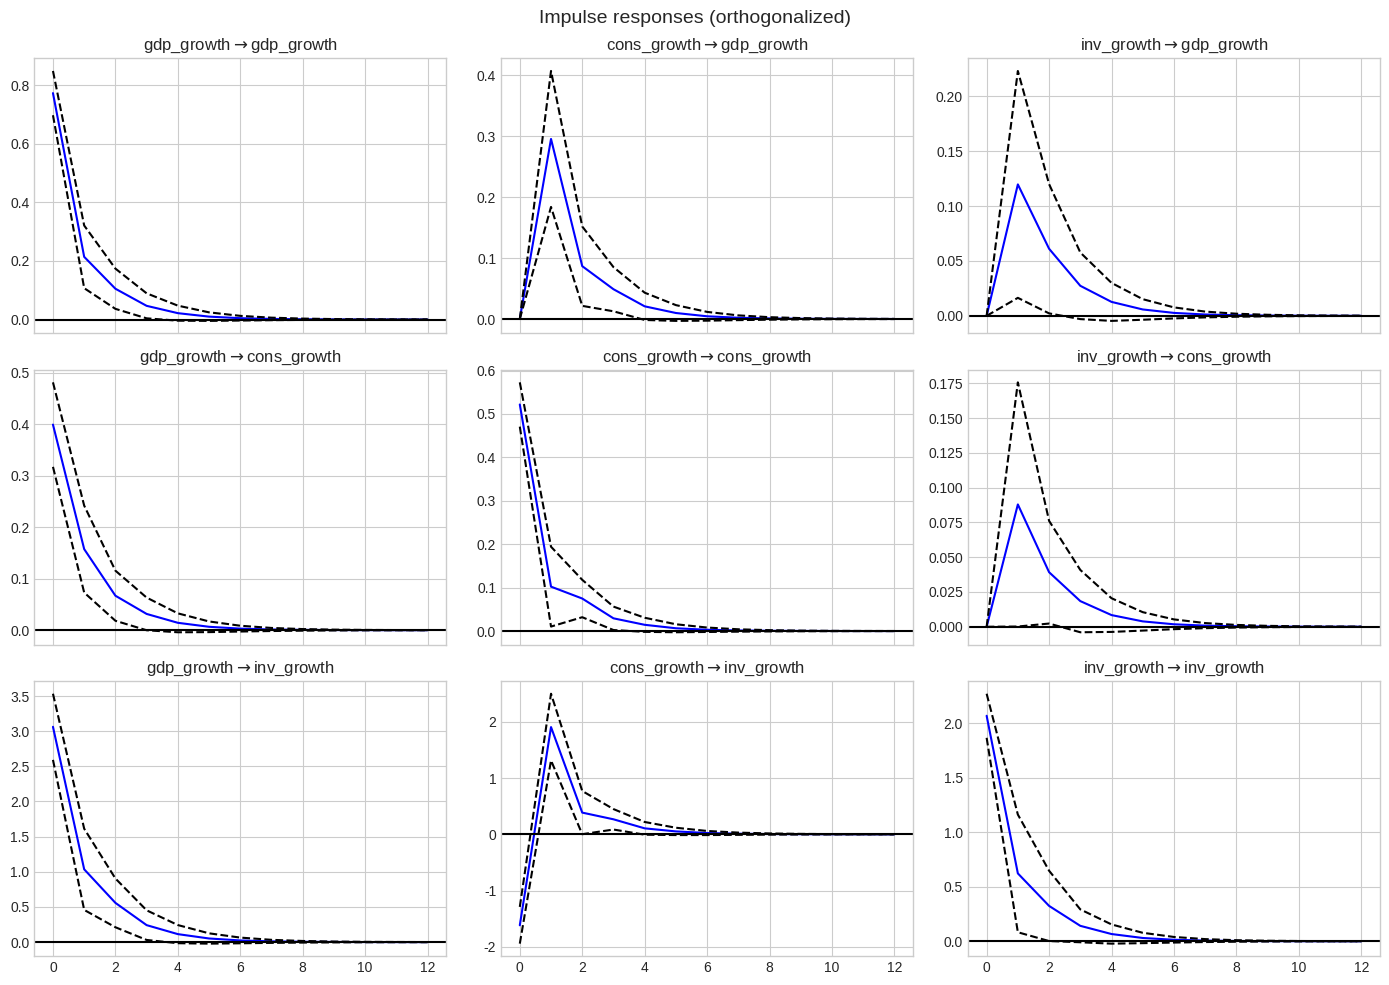

In [14]:
# ============================================
# 14. IRF 전체 플롯
# ============================================

fig = irf.plot(orth=True)
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


## 11. 특정 충격과 특정 변수 반응만 따로 보기
전체 IRF 그림은 정보가 많기 때문에, 실제 해석에서는 특정 조합을 골라 보는 경우가 많습니다.

예를 들어:
- 투자 충격이 GDP 성장에 어떤 영향을 주는가?
- GDP 충격이 소비 성장에 어떤 영향을 주는가?


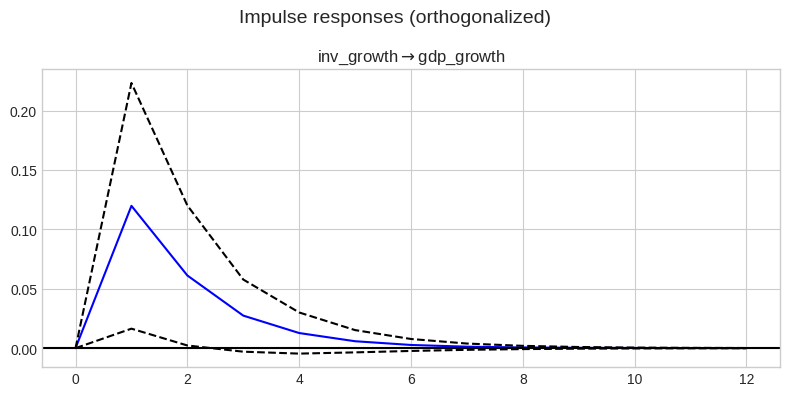

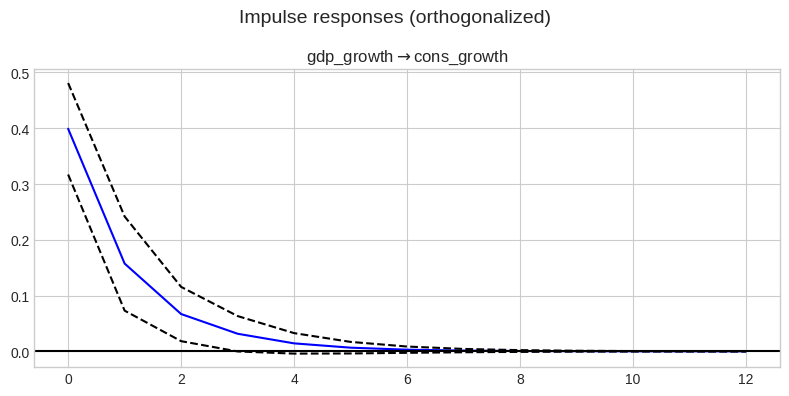

In [15]:
# ============================================
# 15. 특정 IRF 조합 예시
# ============================================

# impulse: 충격을 준 변수
# response: 반응을 보는 변수
fig = irf.plot(impulse="inv_growth", response="gdp_growth", orth=True)
fig.set_size_inches(8, 4)
plt.tight_layout()
plt.show()

fig = irf.plot(impulse="gdp_growth", response="cons_growth", orth=True)
fig.set_size_inches(8, 4)
plt.tight_layout()
plt.show()


## 12. IRF 해석 시 주의점
IRF를 볼 때는 다음을 함께 생각해야 합니다.

1. 반응의 부호가 양(+)인지 음(-)인지
2. 충격 효과가 몇 기까지 지속되는지
3. 반응이 0으로 수렴하는지
4. 직교화(orthogonalization) 방식이 결과에 영향을 줄 수 있는지

특히 `orth=True`인 경우에는 변수 순서(ordering)가 결과에 영향을 줄 수 있습니다.  
따라서 IRF 해석은 기계적으로 하기보다, 변수 배치와 경제적 직관을 함께 검토해야 합니다.


## 13. 예측오차 분산분해 (FEVD)
FEVD는 특정 변수의 예측오차 분산이 어떤 충격들에 의해 설명되는지를 보여줍니다.

쉽게 말해,  
“GDP 성장률의 변동성은 자기 자신의 충격 때문인가, 아니면 소비와 투자의 충격 때문인가?”  
를 비율로 나누어 보는 도구입니다.


In [16]:
# ============================================
# 16. FEVD 계산
# ============================================

fevd = var_results.fevd(12)
print(fevd)


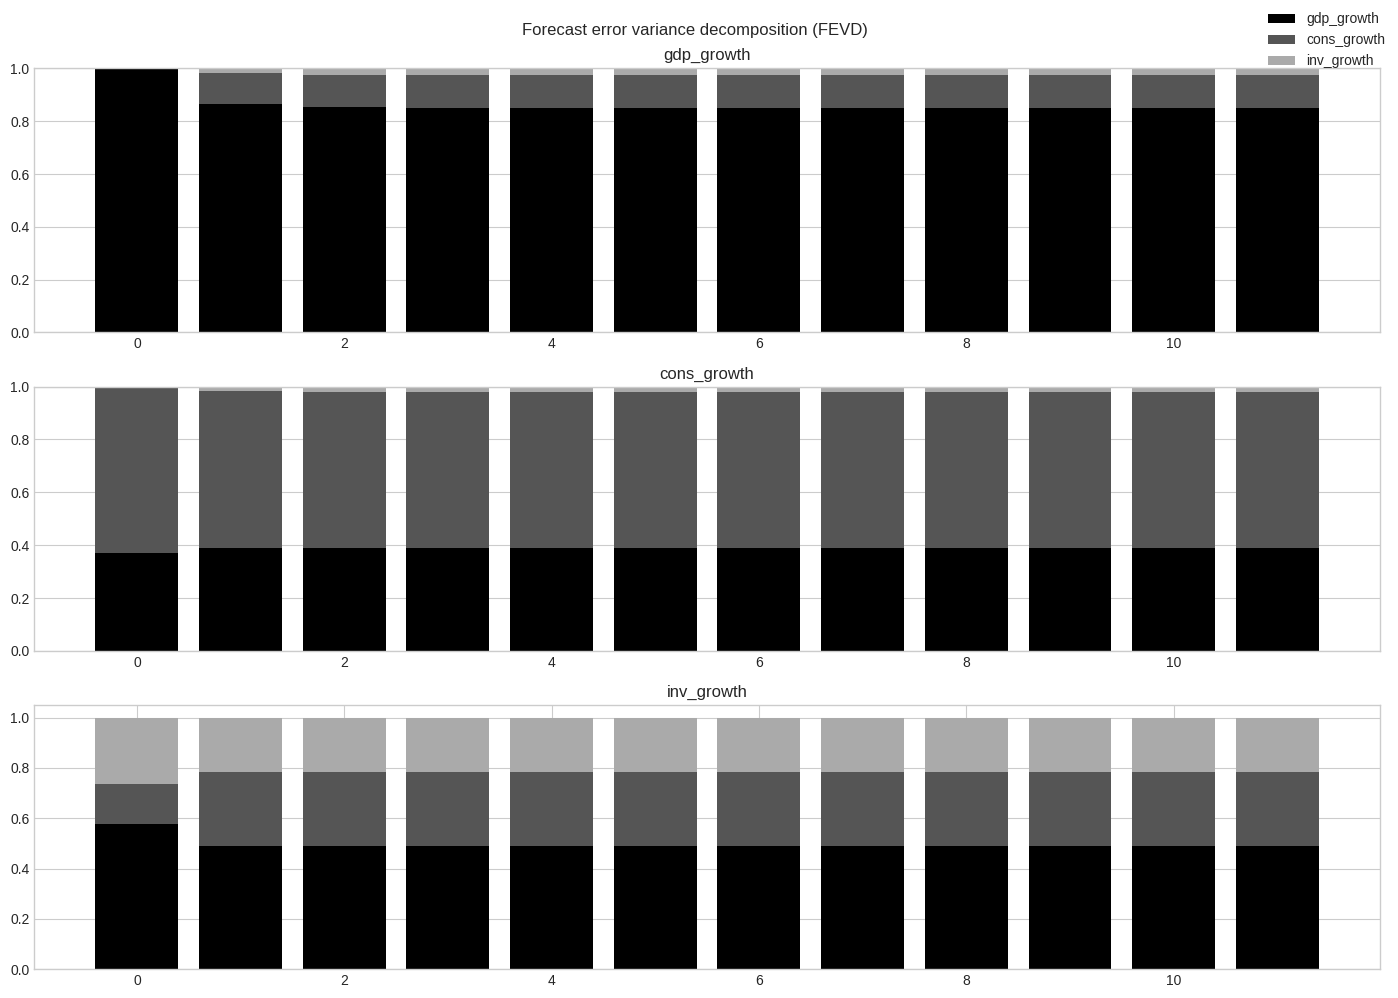

In [17]:
# ============================================
# 17. FEVD 전체 플롯
# ============================================

fig = fevd.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


## 14. FEVD 표 확인
그래프와 함께 수치 표를 같이 보는 것이 해석에 도움이 됩니다.  
아래는 horizon별 분산분해 결과 중 일부를 확인하는 예시입니다.


In [18]:
# ============================================
# 18. FEVD 요약표 확인
# ============================================

for i, var in enumerate(data.columns):
    print(f"===== FEVD for {var} =====")
    fevd_df = pd.DataFrame(
        fevd.decomp[:, i, :],
        columns=data.columns
    )
    display(fevd_df.head(8))
    print("-" * 50)


===== FEVD for gdp_growth =====


,gdp_growth,cons_growth,inv_growth
0,1.000000,0.000000,0.000000
1,0.369003,0.630997,0.000000
2,0.576515,0.160707,0.262779


--------------------------------------------------
===== FEVD for cons_growth =====


,gdp_growth,cons_growth,inv_growth
0,0.863290,0.117446,0.019264
1,0.387804,0.595911,0.016285
2,0.489217,0.292549,0.218234


--------------------------------------------------
===== FEVD for inv_growth =====


,gdp_growth,cons_growth,inv_growth
0,0.852569,0.123851,0.023579
1,0.387739,0.593203,0.019058
2,0.490804,0.291795,0.217401


--------------------------------------------------


## 15. FEVD 해석의 직관
FEVD 해석에서 핵심은 다음과 같습니다.

- 아주 짧은 horizon에서는 자기 자신의 충격 비중이 클 수 있다.
- horizon이 길어질수록 다른 변수의 기여도가 커질 수 있다.
- 특정 변수의 변동이 대부분 자기 충격으로 설명된다면, 시스템 내에서 더 독립적일 수 있다.
- 반대로 다른 변수의 기여가 크다면, 시스템적 연결성이 강하다고 볼 수 있다.


## 16. 간단한 예측까지 수행해 보기
이번 장의 핵심은 해석 도구이지만, VAR 시스템 자체의 예측도 간단히 확인할 수 있습니다.  
다만 이 장에서는 예측 성능보다 **그랜저, IRF, FEVD의 해석**이 중심이라는 점을 기억해야 합니다.


In [19]:
# ============================================
# 19. 마지막 8분기 테스트 예측
# ============================================

test_size = 8
train = data.iloc[:-test_size]
test = data.iloc[-test_size:]

var_test_results = VAR(train).fit(selected_lag)
forecast_values = var_test_results.forecast(train.values[-selected_lag:], steps=len(test))

forecast_df = pd.DataFrame(forecast_values, index=test.index, columns=test.columns)
display(forecast_df.head())


,gdp_growth,cons_growth,inv_growth
2007-12-31,0.457964,0.738487,-1.248278
2008-03-31,0.710034,0.791629,0.569048
2008-06-30,0.762796,0.843991,0.742459
2008-09-30,0.791118,0.858551,0.902342
2008-12-31,0.800577,0.865145,0.947195


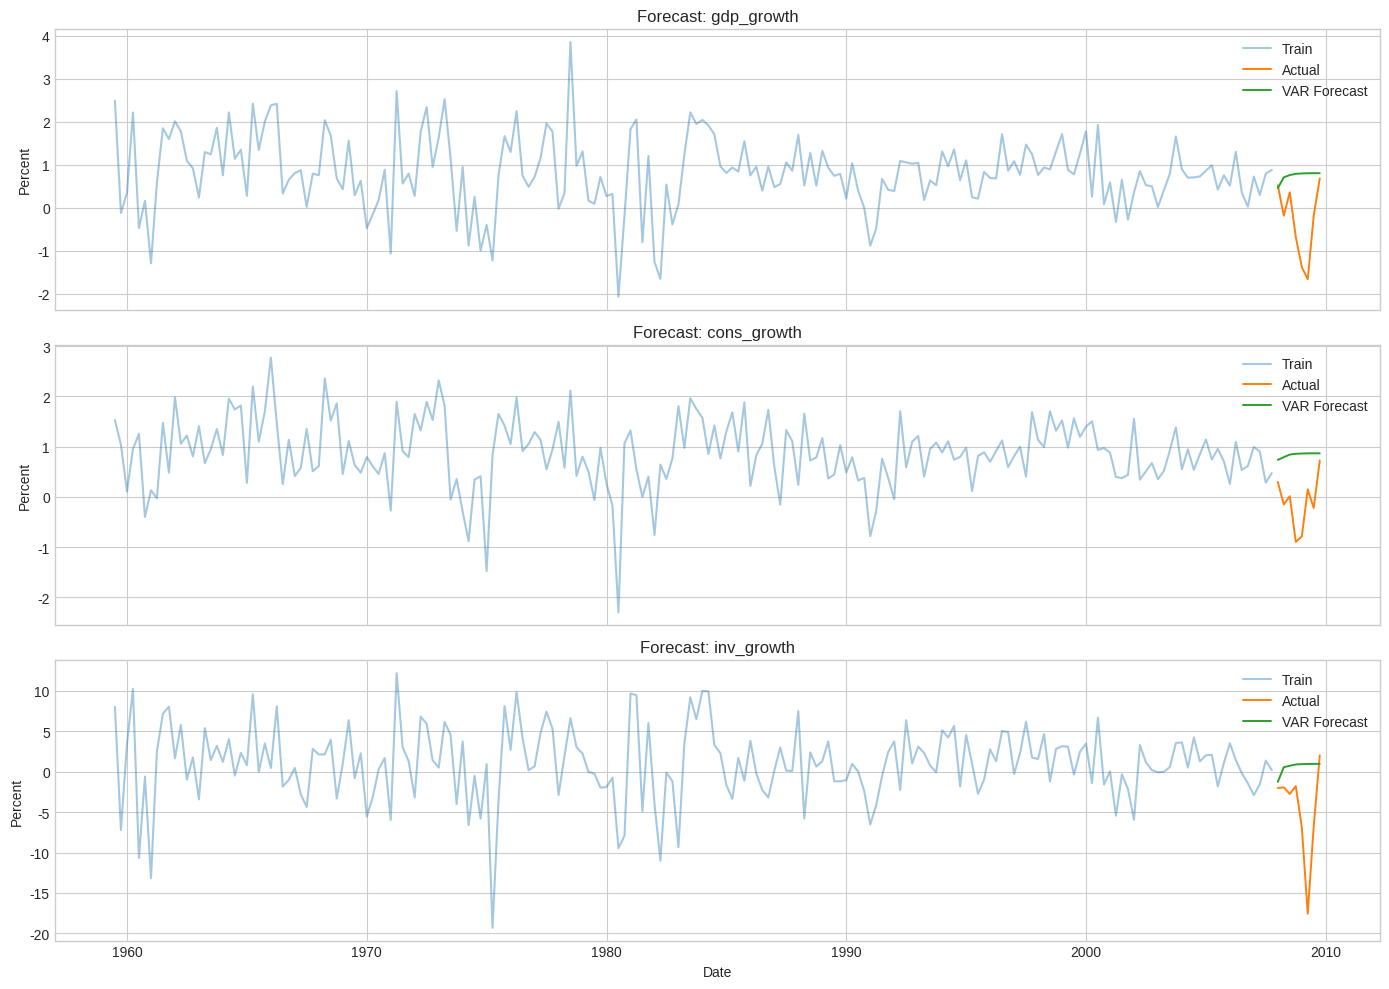

In [20]:
# ============================================
# 20. 테스트 구간 예측 시각화
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, col in enumerate(test.columns):
    axes[i].plot(train.index, train[col], label="Train", alpha=0.4)
    axes[i].plot(test.index, test[col], label="Actual", linewidth=1.4)
    axes[i].plot(forecast_df.index, forecast_df[col], label="VAR Forecast", linewidth=1.4)
    axes[i].set_title(f"Forecast: {col}")
    axes[i].set_ylabel("Percent")
    axes[i].legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 17. 자주 발생하는 실수 (Common Mistakes)
이번 장에서 특히 자주 발생하는 실수는 다음과 같습니다.

1. **그랜저 인과성을 철학적 인과성으로 오해하는 실수**  
   예측 선행성과 정책적 인과는 다릅니다.

2. **비정상 데이터에 그대로 VAR를 적합하는 실수**  
   수준 데이터에 단위근이 있으면 가짜 관계가 강화될 수 있습니다.

3. **IRF 해석에서 변수 순서를 무시하는 실수**  
   직교화된 IRF는 ordering에 민감할 수 있습니다.

4. **FEVD를 단순한 상관 비율처럼 해석하는 실수**  
   FEVD는 동적 시스템 내 예측오차 분산의 분해이지, 단순 상관계수 표가 아닙니다.


## 18. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 그랜저 인과성은 철학적 인과가 아니라 통계적 예측 선행성이다.
- VAR 적합 후에는 계수표보다 그랜저 검정, IRF, FEVD가 더 실무적인 해석 도구가 된다.
- IRF는 충격의 방향, 지속성, 수렴 여부를 보여준다.
- FEVD는 특정 변수 변동성의 원천이 자기 충격인지 시스템 충격인지 분해해 준다.
- 이러한 도구들은 거시경제, 금융, 경영 데이터의 연결 구조를 해석하는 데 매우 유용하다.


## 19. 연습문제 (Exercises)

1. `gdp_growth`, `cons_growth`, `inv_growth` 대신 다른 3개 거시 변수를 선택하여 같은 절차를 반복하시오.

2. 그랜저 인과성 검정 결과에서 p-value가 가장 작은 방향성 쌍을 찾고, 그것이 의미하는 바를 예측 선행성 관점에서 설명하시오.

3. IRF에서 투자 충격이 GDP 성장률에 미치는 반응 곡선을 보고, 부호와 지속 기간을 해석하시오.

4. FEVD 결과에서 어느 변수의 변동성이 자기 자신의 충격에 가장 많이 설명되는지 확인하시오.

5. 직교화된 IRF에서 변수 순서를 바꾸면 결과가 왜 달라질 수 있는지 설명하시오.
